# Multi-Label AMR Classifier  (+ per-drug adaptive class weighting)

**Same as 04-04, but `pos_weight` only applied to drugs where the susceptible/resistant imbalance exceeds 3:1.** Balanced drugs get `pos_weight=1.0` (no weighting), preventing regression on drugs near 1:1 ratio.

**Train on DRIAMS-A (9,443 samples), test on B, C, D. Predict 10-drug resistance simultaneously.**

A single shared MLP with 10 output heads learns resistance patterns across all 10 drugs at once. Label masking handles drugs not tested on a given sample.

**Baseline:** OneVsRest Logistic Regression (10 independent LRs)
**Main model:** Shared `SpectralAttentionMLP` → 10 sigmoid heads with masked BCE loss (adaptive per-drug class weighting, threshold=3.0)
**Preprocessing:** log1p + standardise (fit on A train only)
**Grid search:** 6×6 lr × dropout on A validation


In [1]:
!pip install maldideepkit maldiamrkit seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.9/78.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.4/245.4 kB 869.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.66.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 wh

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted')
    IN_COLAB = True
except ImportError:
    print('Running locally')
    IN_COLAB = False

Mounted at /content/drive
Google Drive mounted


In [3]:
import warnings
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score, accuracy_score)

from maldideepkit.attention.mlp import SpectralAttentionMLP
from maldideepkit.base.data import fit_input_transform, apply_input_transform
from maldiamrkit.evaluation import stratified_species_drug_split

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
if IN_COLAB:
    DRYAD = Path("/content/drive/MyDrive/Flower/DRIAMS-DataSet")
    DATA_ROOT = Path("/content/drive/MyDrive/Flower/DRIAMS-DataSet/Processed/Processing/Analysis/04-03-Wider-Backbone-Ablation")
else:
    DRYAD = Path("/media/asd/8f69beed-e984-445f-b8b3-abbb6a1a4b3f/Dryad-DataSet")
    DATA_ROOT = Path("/media/asd/8f69beed-e984-445f-b8b3-abbb6a1a4b3f/Dryad-DataSet/Processed/Processing/Analysis/04-03-Wider-Backbone-Ablation")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

OUT_DIR = Path("./results_multilabel")
OUT_DIR.mkdir(exist_ok=True)

BIN_COLS = [f"bin_{i}" for i in range(6000)]
DRUGS_10 = ["Ciprofloxacin", "Gentamicin", "Amoxicillin-Clavulanic acid",
            "Piperacillin-Tazobactam", "Cefepime", "Ceftriaxone",
            "Imipenem", "Ceftazidime", "Vancomycin", "Amikacin"]
SITES = ["DRIAMS-A", "DRIAMS-B", "DRIAMS-C", "DRIAMS-D"]
print(f"Drugs: {len(DRUGS_10)}  |  Sites: {SITES}")


Drugs: 10  |  Sites: ['DRIAMS-A', 'DRIAMS-B', 'DRIAMS-C', 'DRIAMS-D']


In [5]:
# =============================================================================
# 1. MULTI-LABEL DATASET (handles NaN = untested drugs)
# =============================================================================

class MultiLabelDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(np.nan_to_num(Y, nan=0.0), dtype=torch.float32)
        self.mask = torch.tensor(~np.isnan(Y), dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.mask[idx]


def load_multilabel_split():
    """Build multi-label X/Y from Processed per-drug CSVs. A = train, B/C/D = test."""
    train_X, train_Y, train_sp = None, None, None
    test_sites = {}

    drug_dirs = {d: d for d in DRUGS_10}  # directory names match drug names

    for site_name in SITES:
        proc_site = f"Proc_{site_name}"
        site_labels = {}   # {code: {drug: label}}
        X_samples = {}     # {code: X_vector}
        sp_samples = {}    # {code: species}
        site_drugs_ok = []

        for drug_name in DRUGS_10:
            p = DATA_ROOT / proc_site / drug_name / "data.csv"
            if not p.exists():
                continue
            df = pd.read_csv(p)
            site_drugs_ok.append(drug_name)
            for _, row in df.iterrows():
                code = row["code"]
                if code not in X_samples:
                    X_samples[code] = row[BIN_COLS].values.astype("float32")
                    sp_samples[code] = row["species"]
                site_labels.setdefault(code, {})[drug_name] = row["label"]

        if not site_drugs_ok:
            continue

        codes = list(X_samples.keys())
        X = np.array([X_samples[c] for c in codes], dtype="float32")
        species = np.array([sp_samples[c] for c in codes])

        # Build Y matrix (N, 10) with NaN for untested
        Y = np.full((len(codes), len(DRUGS_10)), np.nan, dtype=float)
        for i, drug in enumerate(DRUGS_10):
            for j, code in enumerate(codes):
                if drug in site_labels.get(code, {}):
                    Y[j, i] = site_labels[code][drug]

        n_lab = (~np.isnan(Y)).sum(axis=1).mean()
        print(f"  {site_name}: {len(codes)} samples, {len(site_drugs_ok)} drugs, avg {n_lab:.1f} labels/sample")

        if site_name == "DRIAMS-A":
            train_X, train_Y, train_sp = X, Y, species
        else:
            test_sites[site_name] = (X, Y, species)

    print(f"\nTrain (A): {train_X.shape[0]} samples, {len(np.unique(train_sp))} species")
    for s, (Xs, Ys, sps) in test_sites.items():
        print(f"  Test {s}: {Xs.shape[0]} samples, {len(np.unique(sps))} species")
    return train_X, train_Y, train_sp, test_sites

---
## Multi-Label MLP Class Definition

In [6]:
# =============================================================================
# 2. MULTI-LABEL MLP CLASSIFIER  (sklearn-compatible, PyTorch backend)
# =============================================================================

class MultiLabelMaldiMLP(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_dim=512, head_dims=(256, 128), use_attention=False,
                 dropout_high=0.3, dropout_low=0.2,
                 learning_rate=1e-3, weight_decay=0.0,
                 batch_size=64, epochs=50, early_stopping_patience=10,
                 warmup_epochs=0, val_fraction=0.1,
                 random_state=42, verbose=False, device="cpu"):
        self.hidden_dim = hidden_dim
        self.head_dims = head_dims
        self.use_attention = use_attention
        self.dropout_high = dropout_high
        self.dropout_low = dropout_low
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.epochs = epochs
        self.early_stopping_patience = early_stopping_patience
        self.warmup_epochs = warmup_epochs
        self.val_fraction = val_fraction
        self.random_state = random_state
        self.verbose = verbose
        self.device = device

    def _build_model(self, input_dim, n_classes):
        return SpectralAttentionMLP(
            input_dim=input_dim, n_classes=n_classes,
            hidden_dim=self.hidden_dim, head_dims=self.head_dims,
            use_attention=self.use_attention,
            dropout_high=self.dropout_high, dropout_low=self.dropout_low)

    def fit(self, X, Y):
        np.random.seed(self.random_state)
        torch.manual_seed(self.random_state)

        self.n_labels_ = Y.shape[1]
        self.input_dim_ = X.shape[1]

        # ── Adaptive per-drug pos_weight for BCEWithLogitsLoss ──
        # Only apply weighting when S/R imbalance > ADAPTIVE_THRESHOLD (3.0 = 3:1)
        # Balanced drugs get pos_weight=1.0 (no weighting) to avoid regression
        ADAPTIVE_THRESHOLD = 3.0
        self.pos_weights_ = torch.ones(self.n_labels_, dtype=torch.float32, device=self.device)
        for di in range(self.n_labels_):
            valid = ~np.isnan(Y[:, di])
            n_pos = max((Y[valid, di] == 1.0).sum(), 1)
            n_neg = max((Y[valid, di] == 0.0).sum(), 1)
            ratio = n_neg / n_pos
            if ratio > ADAPTIVE_THRESHOLD or (1.0 / ratio) > ADAPTIVE_THRESHOLD:
                self.pos_weights_[di] = ratio
        if self.verbose:
            print(f"  adaptive pos_weights: {[f'{pw:.2f}' for pw in self.pos_weights_.cpu().numpy()]}")

        self.model_ = self._build_model(self.input_dim_, self.n_labels_).to(self.device)

        ds = MultiLabelDataset(X, Y)
        n_val = max(1, int(len(ds) * self.val_fraction))
        n_tr = len(ds) - n_val
        train_ds, val_ds = random_split(ds, [n_tr, n_val],
            generator=torch.Generator().manual_seed(self.random_state))

        train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=self.batch_size * 2, shuffle=False)

        opt_cls = torch.optim.AdamW if self.weight_decay > 0 else torch.optim.Adam
        optimizer = opt_cls(self.model_.parameters(), lr=self.learning_rate,
                            weight_decay=self.weight_decay)
        warmup = max(0, self.warmup_epochs)
        t_max = max(1, self.epochs - warmup)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=t_max, eta_min=1e-6)
        criterion = nn.BCEWithLogitsLoss(reduction="none", pos_weight=self.pos_weights_)

        best_val_loss = float("inf")
        best_state = None
        patience_counter = 0

        for epoch in range(self.epochs):
            self.model_.train()
            train_loss = 0.0
            for xb, yb, mb in train_loader:
                xb, yb, mb = xb.to(self.device), yb.to(self.device), mb.to(self.device)
                if epoch < warmup:
                    for pg in optimizer.param_groups:
                        pg["lr"] = self.learning_rate * (epoch + 1) / warmup
                optimizer.zero_grad()
                logits = self.model_(xb)
                loss = criterion(logits, yb)
                loss = (loss * mb).sum() / mb.sum()
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            if epoch >= warmup:
                scheduler.step()

            self.model_.eval()
            val_loss = 0.0
            with torch.no_grad():
                for xb, yb, mb in val_loader:
                    xb, yb, mb = xb.to(self.device), yb.to(self.device), mb.to(self.device)
                    logits = self.model_(xb)
                    loss = criterion(logits, yb)
                    loss = (loss * mb).sum() / mb.sum()
                    val_loss += loss.item()

            val_loss /= len(val_loader)
            train_loss /= len(train_loader)

            if self.verbose:
                print(f"  Epoch {epoch+1:3d}/{self.epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in self.model_.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= self.early_stopping_patience:
                    if self.verbose:
                        print(f"  Early stopping at epoch {epoch+1}")
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)
        self.model_.eval()
        self.is_fitted_ = True
        return self

    def predict_proba(self, X):
        X_t = torch.tensor(X, dtype=torch.float32).to(self.device)
        with torch.no_grad():
            logits = self.model_(X_t)
            proba = torch.sigmoid(logits).cpu().numpy()
        return proba

    def predict(self, X, thresholds=None):
        proba = self.predict_proba(X)
        if thresholds is None:
            thresholds = [0.5] * self.n_labels_
        return (proba >= np.array(thresholds)).astype(int)

---
## Data Loading + Cross-Site Split

In [13]:
import joblib
# =============================================================================
# 3. LOAD DATA + CROSS-SITE SPLIT (train A, test B/C/D) - CACHED
# =============================================================================

cache_path = DATA_ROOT / "cross_site_multilabel_data.joblib"

if cache_path.exists():
    print(f"Loading cross-site data from cache: {cache_path}")
    X_train_raw, Y_train_raw, sp_train_raw, test_data_raw = joblib.load(cache_path)
else:
    print("Loading data from Processed CSVs (first time)...")
    X_train_raw, Y_train_raw, sp_train_raw, test_data_raw = load_multilabel_split()
    joblib.dump((X_train_raw, Y_train_raw, sp_train_raw, test_data_raw), cache_path)
    print(f"Data saved to cache: {cache_path}")

# Species-stratified A split: train 70% / val 30%
# stratified_species_drug_split handles rare species via min_count=2
idx_tr, idx_v, _, _ = stratified_species_drug_split(
    np.arange(len(Y_train_raw)).reshape(-1, 1),
    np.zeros(len(Y_train_raw)),  # dummy labels — stratification is by species only
    species=sp_train_raw,
    test_size=0.30,
    random_state=SEED)
idx_tr = idx_tr.flatten().astype(int)
idx_v = idx_v.flatten().astype(int)

X_train = X_train_raw[idx_tr]
Y_train = Y_train_raw[idx_tr]
X_val = X_train_raw[idx_v]
Y_val = Y_train_raw[idx_v]
print(f"\nSplit: A train={len(X_train)}  A val={len(X_val)}")

# Preprocess: fit on A train, apply to all
state = fit_input_transform(X_train, "log1p+standardize")
X_train_pp = apply_input_transform(X_train, state)
X_val_pp = apply_input_transform(X_val, state)
print("Preprocessing done.")

# Apply preprocessing to test sites
test_pp = {}
for site, (Xs, Ys, _) in test_data_raw.items():
    test_pp[site] = (apply_input_transform(Xs, state), Ys)
    n_lab = (~np.isnan(Ys)).sum(axis=1).mean()
    print(f"  Test {site}: {Xs.shape[0]} samples preprocessed, avg {n_lab:.1f} labels/sample")

# Build combined test set
if test_pp:
    X_combined = np.concatenate([t[0] for t in test_pp.values()])
    Y_combined = np.concatenate([t[1] for t in test_pp.values()])
    test_pp["B+C+D"] = (X_combined, Y_combined)
    print(f"  Test B+C+D combined: {X_combined.shape[0]} samples")

Loading cross-site data from cache: /content/drive/MyDrive/Flower/DRIAMS-DataSet/Processed/Processing/Analysis/04-03-Wider-Backbone-Ablation/cross_site_multilabel_data.joblib

Split: A train=6586  A val=2823
Preprocessing done.
  Test DRIAMS-B: 2321 samples preprocessed, avg 5.0 labels/sample
  Test DRIAMS-C: 4552 samples preprocessed, avg 4.9 labels/sample
  Test DRIAMS-D: 10360 samples preprocessed, avg 5.7 labels/sample
  Test B+C+D combined: 17233 samples


---
## Baseline: OneVsRest Logistic Regression

In [14]:
# =============================================================================
# 4. BASELINE: OneVsRest Logistic Regression
# =============================================================================

C_grid = np.linspace(5e-5, 1e-3, 15)
thresholds = np.linspace(0.05, 0.95, 91)

lr_models = {}
lr_results = {}
for di, drug in enumerate(tqdm(DRUGS_10, desc="LR per drug")):
    # Training samples labeled for this drug
    tr_mask = ~np.isnan(Y_train[:, di])
    X_tr, y_tr = X_train_pp[tr_mask], Y_train[tr_mask, di].astype(int)
    val_mask = ~np.isnan(Y_val[:, di])
    X_v, y_v = X_val_pp[val_mask], Y_val[val_mask, di].astype(int)

    if len(np.unique(y_tr)) < 2 or len(np.unique(y_v)) < 2:
        lr_results[drug] = {"A-val_BalAcc": np.nan, "A-val_AUC": np.nan}
        continue

    # GridSearchCV
    grid = GridSearchCV(
        LogisticRegression(penalty="l2", solver="lbfgs", class_weight="balanced", max_iter=5000, random_state=SEED),
        param_grid={"C": C_grid}, cv=3, scoring="balanced_accuracy", n_jobs=-1, verbose=0)
    grid.fit(X_tr, y_tr)
    lr = grid.best_estimator_

    # Threshold tuning
    proba_v = lr.predict_proba(X_v)[:, 1]
    best_t = thresholds[np.argmax([balanced_accuracy_score(y_v, proba_v >= t) for t in thresholds])]

    lr_models[drug] = (lr, best_t)
    lr_results[drug] = {"A-val_BalAcc": balanced_accuracy_score(y_v, proba_v >= best_t),
                        "A-val_AUC": roc_auc_score(y_v, proba_v)}

    for st, (X_st, Y_st) in test_pp.items():
        ts_mask = ~np.isnan(Y_st[:, di])
        if ts_mask.sum() < 2: continue
        X_ts, y_ts = X_st[ts_mask], Y_st[ts_mask, di].astype(int)
        proba = lr.predict_proba(X_ts)[:, 1]
        preds = proba >= best_t
        lr_results[drug][f"{st}_BalAcc"] = balanced_accuracy_score(y_ts, preds)
        lr_results[drug][f"{st}_AUC"] = roc_auc_score(y_ts, proba)

print("\nLR baseline done.")

LR per drug: 100%|██████████| 10/10 [09:59<00:00, 59.97s/it]


LR baseline done.


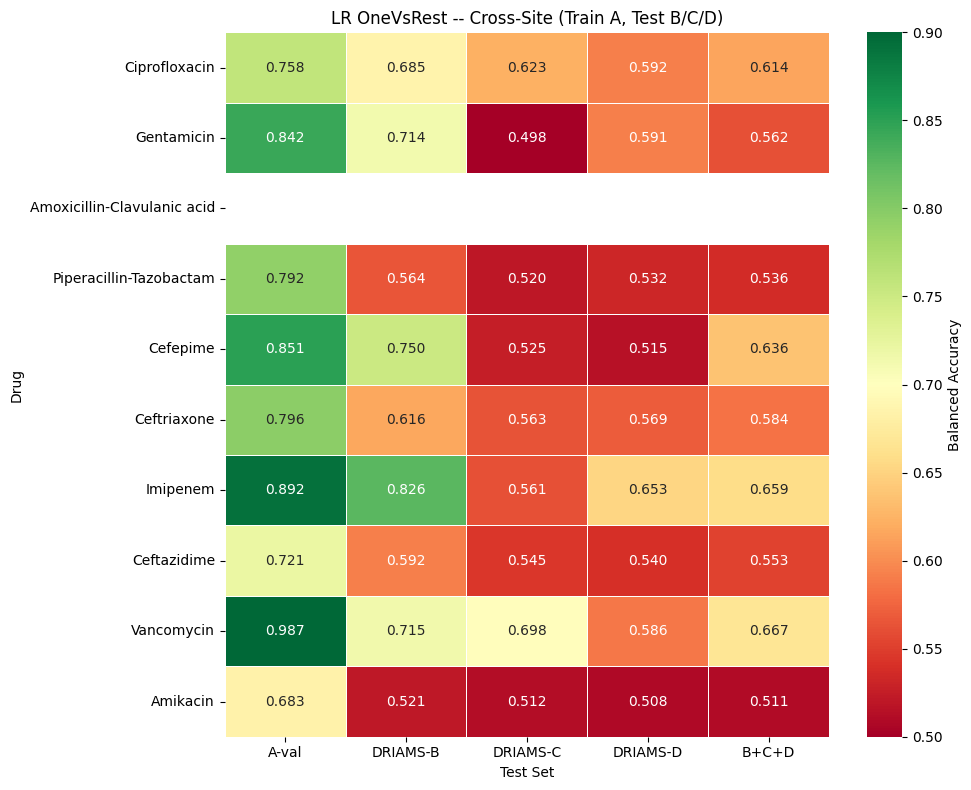


LR Per-Drug BalAcc:
                                A-val  DRIAMS-B  DRIAMS-C  DRIAMS-D     B+C+D
Ciprofloxacin                0.757899  0.684709  0.623437  0.591936  0.614085
Gentamicin                   0.842353  0.713535  0.498211  0.590938  0.561696
Amoxicillin-Clavulanic acid       NaN       NaN       NaN       NaN       NaN
Piperacillin-Tazobactam      0.792197  0.564257  0.519748  0.532127  0.536080
Cefepime                     0.850783  0.750276  0.525191  0.514828  0.636125
Ceftriaxone                  0.795555  0.616163  0.562554  0.568994  0.583784
Imipenem                     0.891534  0.825512  0.561476  0.653101  0.659289
Ceftazidime                  0.720532  0.591636  0.544503  0.539919  0.552717
Vancomycin                   0.987169  0.715471  0.697992  0.586123  0.667443
Amikacin                     0.683248  0.521010  0.511593  0.508144  0.510730


In [15]:
# ── LR Heatmap ──
sites_order = ["A-val_BalAcc", "DRIAMS-B_BalAcc", "DRIAMS-C_BalAcc", "DRIAMS-D_BalAcc", "B+C+D_BalAcc"]
data = {}
for drug in DRUGS_10:
    row = [lr_results[drug].get(k, np.nan) for k in sites_order]
    data[drug] = row

fig, ax = plt.subplots(figsize=(10, 8))
hm = pd.DataFrame(data, index=[s.replace("_BalAcc", "") for s in sites_order]).T
sns.heatmap(hm, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.5, vmax=0.9,
            linewidths=0.5, cbar_kws={"label": "Balanced Accuracy"}, ax=ax)
ax.set_title("LR OneVsRest -- Cross-Site (Train A, Test B/C/D)")
ax.set_xlabel("Test Set"); ax.set_ylabel("Drug")
plt.tight_layout()
plt.savefig(OUT_DIR / "lr_multilabel_heatmap.pdf", bbox_inches="tight")
plt.show()

print("\nLR Per-Drug BalAcc:")
print(hm.to_string())

---
## Shared MLP: Grid Search + Training

In [16]:
# =============================================================================
# 5. SHARED MLP -- GRID SEARCH (lr x dropout)
# =============================================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

LR_GRID = np.linspace(1e-4, 5e-4, 6)
DROP_GRID = np.linspace(0.2, 0.6, 6)
print(f"Grid: {len(LR_GRID)} lr x {len(DROP_GRID)} dropout = {len(LR_GRID)*len(DROP_GRID)} combos")

best_balacc = -1
best_lr = None; best_dh = None

for lr in LR_GRID:
    for d in DROP_GRID:
        dh, dl = d, d / 2
        mlp = MultiLabelMaldiMLP(
            hidden_dim=512, head_dims=(256, 128), use_attention=False,
            dropout_high=dh, dropout_low=dl,
            learning_rate=lr, weight_decay=1e-3,
            batch_size=64, epochs=50, early_stopping_patience=10,
            warmup_epochs=10, val_fraction=0.1,
            random_state=SEED, verbose=False, device=device)
        mlp.fit(X_train_pp, Y_train)

        proba_v = mlp.predict_proba(X_val_pp)
        # Per-drug threshold tuned BalAcc on val
        per_drug_ba = []
        for di in range(10):
            vm = ~np.isnan(Y_val[:, di])
            if vm.sum() < 2: continue
            pv = proba_v[vm, di]; yv = Y_val[vm, di].astype(int)
            bt = thresholds[np.argmax([balanced_accuracy_score(yv, pv >= t) for t in thresholds])]
            per_drug_ba.append(balanced_accuracy_score(yv, pv >= bt))

        macro_ba = np.mean(per_drug_ba) if per_drug_ba else 0.0
        mark = " *" if macro_ba > best_balacc else ""
        print(f"  lr={lr:.1e}  drop=({dh:.2f},{dl:.2f})  macro_BalAcc={macro_ba:.4f}{mark}")
        if macro_ba > best_balacc:
            best_balacc = macro_ba; best_lr = lr; best_dh = dh

print(f"\nBest: lr={best_lr:.1e} drop=({best_dh:.2f})  macro_BalAcc={best_balacc:.4f}")

Device: cuda
Grid: 6 lr x 6 dropout = 36 combos
  lr=1.0e-04  drop=(0.20,0.10)  macro_BalAcc=0.8226 *
  lr=1.0e-04  drop=(0.28,0.14)  macro_BalAcc=0.8219
  lr=1.0e-04  drop=(0.36,0.18)  macro_BalAcc=0.8215
  lr=1.0e-04  drop=(0.44,0.22)  macro_BalAcc=0.8205
  lr=1.0e-04  drop=(0.52,0.26)  macro_BalAcc=0.8119
  lr=1.0e-04  drop=(0.60,0.30)  macro_BalAcc=0.8174
  lr=1.8e-04  drop=(0.20,0.10)  macro_BalAcc=0.8278 *
  lr=1.8e-04  drop=(0.28,0.14)  macro_BalAcc=0.8155
  lr=1.8e-04  drop=(0.36,0.18)  macro_BalAcc=0.8130
  lr=1.8e-04  drop=(0.44,0.22)  macro_BalAcc=0.8212
  lr=1.8e-04  drop=(0.52,0.26)  macro_BalAcc=0.8086
  lr=1.8e-04  drop=(0.60,0.30)  macro_BalAcc=0.8110
  lr=2.6e-04  drop=(0.20,0.10)  macro_BalAcc=0.8035
  lr=2.6e-04  drop=(0.28,0.14)  macro_BalAcc=0.8249
  lr=2.6e-04  drop=(0.36,0.18)  macro_BalAcc=0.8206
  lr=2.6e-04  drop=(0.44,0.22)  macro_BalAcc=0.8113
  lr=2.6e-04  drop=(0.52,0.26)  macro_BalAcc=0.8197
  lr=2.6e-04  drop=(0.60,0.30)  macro_BalAcc=0.8138
  lr=3.4e-04

In [17]:
# =============================================================================
# 6. RETRAIN BEST MLP + THRESHOLD TUNING
# =============================================================================

mlp_best = MultiLabelMaldiMLP(
    hidden_dim=512, head_dims=(256, 128), use_attention=False,
    dropout_high=best_dh, dropout_low=best_dh/2,
    learning_rate=best_lr, weight_decay=1e-4,
    batch_size=64, epochs=100, early_stopping_patience=15,
    warmup_epochs=10, val_fraction=0.1,
    random_state=SEED, verbose=True, device=device)
mlp_best.fit(X_train_pp, Y_train)

# Per-drug threshold tuning on A validation
proba_val = mlp_best.predict_proba(X_val_pp)
mlp_thresholds = []
for di in range(10):
    vm = ~np.isnan(Y_val[:, di])
    if vm.sum() < 2:
        mlp_thresholds.append(0.5)
        continue
    pv = proba_val[vm, di]; yv = Y_val[vm, di].astype(int)
    bt = thresholds[np.argmax([balanced_accuracy_score(yv, pv >= t) for t in thresholds])]
    mlp_thresholds.append(bt)
mlp_thresholds = np.array(mlp_thresholds)
print(f"\nPer-drug thresholds: {[f'{t:.2f}' for t in mlp_thresholds]}")

# Evaluate on all test sets
mlp_results = {}
for st, (X_st, Y_st) in [("A-val", (X_val_pp, Y_val))] + list(test_pp.items()):
    proba = mlp_best.predict_proba(X_st)
    mlp_results[st] = {}
    for di, drug in enumerate(DRUGS_10):
        tm = ~np.isnan(Y_st[:, di])
        if tm.sum() < 2:
            mlp_results[st][drug] = np.nan
            continue
        preds = (proba[tm, di] >= mlp_thresholds[di])
        yt = Y_st[tm, di].astype(int)
        mlp_results[st][drug] = balanced_accuracy_score(yt, preds)

print("\nMLP done.")

  pos_weights: ['3.94', '4.23', '1.00', '3.82', '4.69', '3.02', '4.42', '7.76', '52.69', '108.23']
  Epoch   1/100  train_loss=1.0991  val_loss=0.9883
  Epoch   2/100  train_loss=0.9538  val_loss=0.9081
  Epoch   3/100  train_loss=0.8727  val_loss=0.8545
  Epoch   4/100  train_loss=0.7971  val_loss=0.8001
  Epoch   5/100  train_loss=0.7224  val_loss=0.7556
  Epoch   6/100  train_loss=0.6474  val_loss=0.7087
  Epoch   7/100  train_loss=0.5615  val_loss=0.6807
  Epoch   8/100  train_loss=0.4894  val_loss=0.6724
  Epoch   9/100  train_loss=0.4238  val_loss=0.7093
  Epoch  10/100  train_loss=0.3710  val_loss=0.6895
  Epoch  11/100  train_loss=0.3282  val_loss=0.7120
  Epoch  12/100  train_loss=0.2854  val_loss=0.6848
  Epoch  13/100  train_loss=0.2493  val_loss=0.7848
  Epoch  14/100  train_loss=0.2275  val_loss=0.7938
  Epoch  15/100  train_loss=0.1977  val_loss=0.8531
  Epoch  16/100  train_loss=0.1637  val_loss=0.8123
  Epoch  17/100  train_loss=0.1412  val_loss=0.8481
  Epoch  18/100  

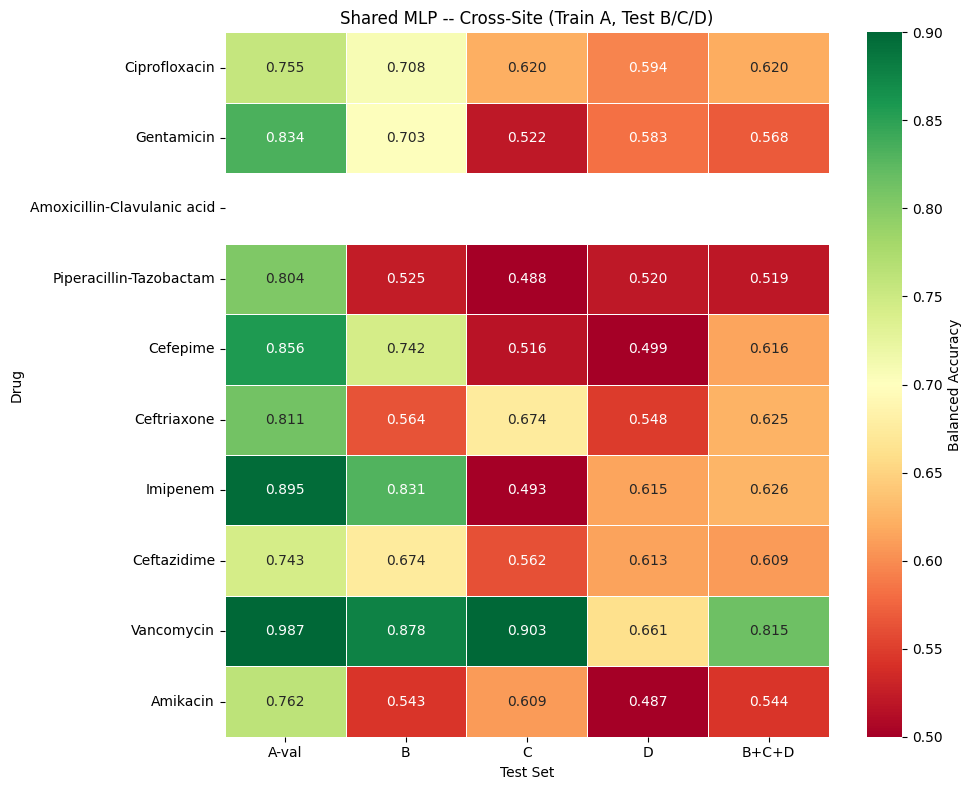


MLP Per-Drug BalAcc:
                                A-val         B         C         D     B+C+D
Ciprofloxacin                0.755189  0.708095  0.620390  0.594418  0.620146
Gentamicin                   0.834248  0.702704  0.521749  0.582660  0.567700
Amoxicillin-Clavulanic acid       NaN       NaN       NaN       NaN       NaN
Piperacillin-Tazobactam      0.803636  0.524961  0.487760  0.520434  0.519176
Cefepime                     0.856270  0.742392  0.516100  0.498829  0.615608
Ceftriaxone                  0.811146  0.563964  0.674392  0.548116  0.624763
Imipenem                     0.895412  0.830650  0.493102  0.614735  0.626036
Ceftazidime                  0.742754  0.673915  0.561893  0.612658  0.609111
Vancomycin                   0.986741  0.877561  0.903204  0.661081  0.814757
Amikacin                     0.761701  0.543030  0.608717  0.486586  0.543727


In [18]:
# ── MLP Heatmap ──
mlp_data = {}
for drug in DRUGS_10:
    row = [mlp_results[st].get(drug, np.nan) for st in ["A-val", "DRIAMS-B", "DRIAMS-C", "DRIAMS-D", "B+C+D"]]
    mlp_data[drug] = row

fig, ax = plt.subplots(figsize=(10, 8))
hm_mlp = pd.DataFrame(mlp_data, index=["A-val", "B", "C", "D", "B+C+D"]).T
sns.heatmap(hm_mlp, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.5, vmax=0.9,
            linewidths=0.5, cbar_kws={"label": "Balanced Accuracy"}, ax=ax)
ax.set_title("Shared MLP -- Cross-Site (Train A, Test B/C/D)")
ax.set_xlabel("Test Set"); ax.set_ylabel("Drug")
plt.tight_layout()
plt.savefig(OUT_DIR / "mlp_multilabel_heatmap.pdf", bbox_inches="tight")
plt.show()

print("\nMLP Per-Drug BalAcc:")
print(hm_mlp.to_string())

---
## LR vs MLP Comparison

           Drug  LR_BalAcc  MLP_BalAcc  LR_Aval  MLP_Aval
  Ciprofloxacin   0.614085    0.620146 0.757899  0.755189
     Gentamicin   0.561696    0.567700 0.842353  0.834248
Amoxicillin-Cla        NaN         NaN      NaN       NaN
Piperacillin-Ta   0.536080    0.519176 0.792197  0.803636
       Cefepime   0.636125    0.615608 0.850783  0.856270
    Ceftriaxone   0.583784    0.624763 0.795555  0.811146
       Imipenem   0.659289    0.626036 0.891534  0.895412
    Ceftazidime   0.552717    0.609111 0.720532  0.742754
     Vancomycin   0.667443    0.814757 0.987169  0.986741
       Amikacin   0.510730    0.543727 0.683248  0.761701


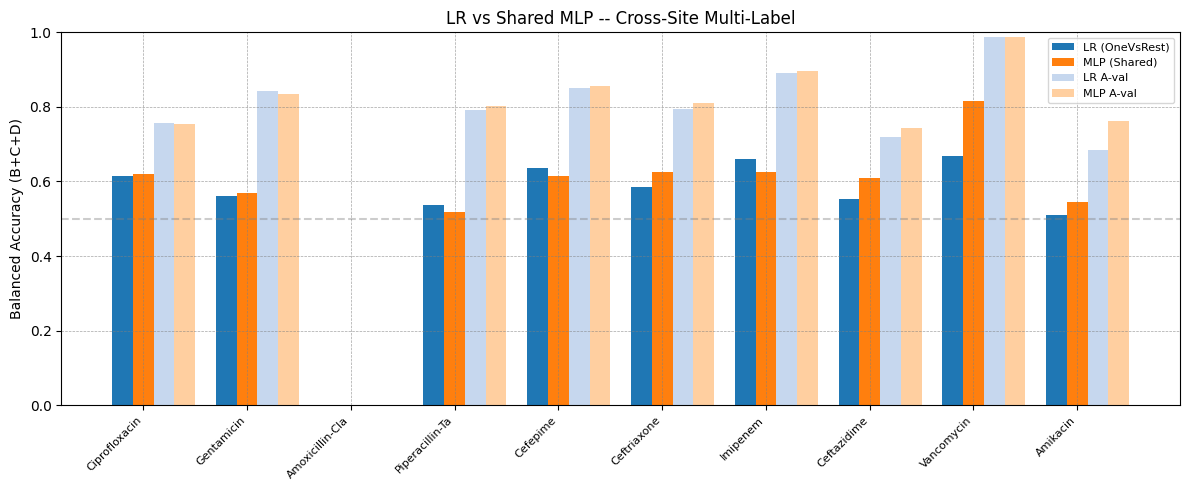

In [19]:
# =============================================================================
# 7. LR vs MLP COMPARISON
# =============================================================================

rows = []
for drug in DRUGS_10:
    lr_ba = lr_results[drug].get("B+C+D_BalAcc", np.nan)
    mlp_ba = mlp_results["B+C+D"].get(drug, np.nan)
    lr_av = lr_results[drug].get("A-val_BalAcc", np.nan)
    mlp_av = mlp_results["A-val"].get(drug, np.nan)
    rows.append({"Drug": drug, "LR_BalAcc": lr_ba, "MLP_BalAcc": mlp_ba,
                 "LR_Aval": lr_av, "MLP_Aval": mlp_av})

df_comp = pd.DataFrame(rows)
df_comp_display = df_comp.copy()
df_comp_display["Drug"] = df_comp_display["Drug"].str.slice(0, 15)
print(df_comp_display.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_comp)); w = 0.2
ax.bar(x - w, df_comp["LR_BalAcc"], w, label="LR (OneVsRest)", color="#1f77b4")
ax.bar(x,      df_comp["MLP_BalAcc"], w, label="MLP (Shared)", color="#ff7f0e")
ax.bar(x + w,  df_comp["LR_Aval"], w, label="LR A-val", color="#aec7e8", alpha=0.7)
ax.bar(x + 2*w, df_comp["MLP_Aval"], w, label="MLP A-val", color="#ffbb78", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([d[:15] for d in df_comp["Drug"]], fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Balanced Accuracy (B+C+D)"); ax.set_title("LR vs Shared MLP -- Cross-Site Multi-Label")
ax.legend(fontsize=8); ax.set_ylim(0, 1); ax.axhline(0.5, color="gray", ls="--", alpha=0.4)
plt.grid(True, ls='--', lw=0.5, color='gray', alpha=0.7)
plt.tight_layout(); plt.savefig(OUT_DIR / "multilabel_lr_vs_mlp.pdf")
plt.show()

In [20]:
print("\nDone. Multi-label results saved to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*.pdf")):
    print(f"  {f.name}")


Done. Multi-label results saved to /content/results_multilabel
  lr_multilabel_heatmap.pdf
  mlp_multilabel_heatmap.pdf
  multilabel_lr_vs_mlp.pdf


## Aggregated Shared MLP (A+B+C+D → species-stratified 70/15/15)  [+ adaptive class weighting]


Loading aggregated data from cache: /content/drive/MyDrive/Flower/DRIAMS-DataSet/Processed/Processing/Analysis/04-03-Wider-Backbone-Ablation/aggregated_multilabel_data.npz
Total aggregated: 26642 samples, 279 species
Split: train=18648  val=3997  test=3997
Preprocessing done.

Grid search: 6 lr x 6 dropout = 36 combos
  lr=1.0e-04  drop=(0.20,0.10)  macro_BalAcc=0.7844 *
  lr=1.0e-04  drop=(0.28,0.14)  macro_BalAcc=0.7866 *
  lr=1.0e-04  drop=(0.36,0.18)  macro_BalAcc=0.7809
  lr=1.0e-04  drop=(0.44,0.22)  macro_BalAcc=0.7765
  lr=1.0e-04  drop=(0.52,0.26)  macro_BalAcc=0.7811
  lr=1.0e-04  drop=(0.60,0.30)  macro_BalAcc=0.7825
  lr=1.8e-04  drop=(0.20,0.10)  macro_BalAcc=0.7807
  lr=1.8e-04  drop=(0.28,0.14)  macro_BalAcc=0.7789
  lr=1.8e-04  drop=(0.36,0.18)  macro_BalAcc=0.7753
  lr=1.8e-04  drop=(0.44,0.22)  macro_BalAcc=0.7786
  lr=1.8e-04  drop=(0.52,0.26)  macro_BalAcc=0.7776
  lr=1.8e-04  drop=(0.60,0.30)  macro_BalAcc=0.7791
  lr=2.6e-04  drop=(0.20,0.10)  macro_BalAcc=0.7796


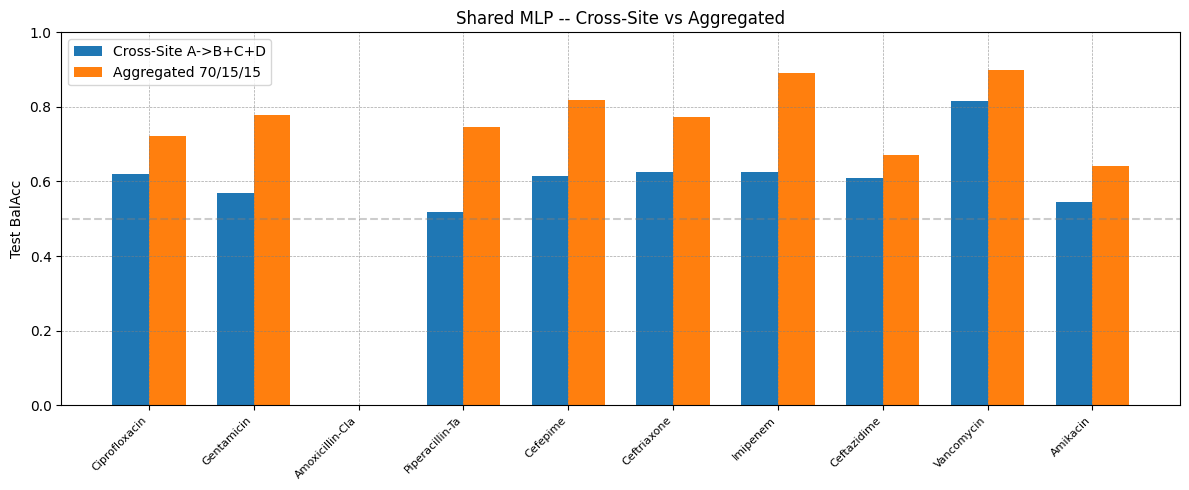


Cross-Site vs Aggregated comparison:
           Drug  Cross-Site (A->B+C+D)  Aggregated (70/15/15)
  Ciprofloxacin               0.620146               0.722988
     Gentamicin               0.567700               0.777264
Amoxicillin-Cla                    NaN                    NaN
Piperacillin-Ta               0.519176               0.745179
       Cefepime               0.615608               0.817200
    Ceftriaxone               0.624763               0.772061
       Imipenem               0.626036               0.890770
    Ceftazidime               0.609111               0.672252
     Vancomycin               0.814757               0.899670
       Amikacin               0.543727               0.642702


In [23]:
# =============================================================================
# 8. AGGREGATED SHARED MLP (all 4 sites A+B+C+D -> species-stratified split)
# =============================================================================

cache_path = DATA_ROOT / "aggregated_multilabel_data.npz"

if cache_path.exists():
    print(f"Loading aggregated data from cache: {cache_path}")
    cached = np.load(cache_path, allow_pickle=True)
    X_all = cached['X_all']
    Y_all = cached['Y_all']
    sp_all = cached['sp_all']
else:
    print("Loading aggregated data from all 4 sites (first time)...")
    X_train_raw, Y_train_raw, sp_train_raw, test_data_raw = load_multilabel_split()

    # Concatenate ALL 4 sites (not just A)
    X_all = np.concatenate([X_train_raw] + [v[0] for v in test_data_raw.values()])
    Y_all = np.concatenate([Y_train_raw] + [v[1] for v in test_data_raw.values()])
    sp_all = np.concatenate([sp_train_raw] + [v[2] for v in test_data_raw.values()])

    np.savez_compressed(cache_path, X_all=X_all, Y_all=Y_all, sp_all=sp_all)
    print(f"Data saved to cache: {cache_path}")

print(f"Total aggregated: {X_all.shape[0]} samples, {len(np.unique(sp_all))} species")

# Species-stratified split: train 70% / val 15% / test 15%
idx_trval, idx_test, _, _ = stratified_species_drug_split(
    np.arange(len(Y_all)).reshape(-1, 1),
    np.zeros(len(Y_all)),  # dummy labels
    species=sp_all,
    test_size=0.15,
    random_state=SEED)
idx_trval = idx_trval.flatten().astype(int)
idx_test = idx_test.flatten().astype(int)

X_trval, Y_trval, sp_trval = X_all[idx_trval], Y_all[idx_trval], sp_all[idx_trval]
X_test, Y_test = X_all[idx_test], Y_all[idx_test]

val_frac = 0.15 / 0.85
idx_train, idx_val, _, _ = stratified_species_drug_split(
    np.arange(len(Y_trval)).reshape(-1, 1),
    np.zeros(len(Y_trval)),
    species=sp_trval,
    test_size=val_frac,
    random_state=SEED)
idx_train = idx_train.flatten().astype(int); idx_val = idx_val.flatten().astype(int)
X_train, Y_train = X_trval[idx_train], Y_trval[idx_train]
X_val, Y_val = X_trval[idx_val], Y_trval[idx_val]

print(f"Split: train={X_train.shape[0]}  val={X_val.shape[0]}  test={X_test.shape[0]}")

# Preprocess
state_agg = fit_input_transform(X_train, "log1p+standardize")
X_train_pp = apply_input_transform(X_train, state_agg)
X_val_pp   = apply_input_transform(X_val, state_agg)
X_test_pp  = apply_input_transform(X_test, state_agg)
print("Preprocessing done.")

# ── Grid search (6x6 lr x dropout, 36 combos) ──
print(f"\nGrid search: {len(LR_GRID)} lr x {len(DROP_GRID)} dropout = {len(LR_GRID)*len(DROP_GRID)} combos")
agg_best_balacc = -1; agg_best_lr = None; agg_best_dh = None

for lr in LR_GRID:
    for d in DROP_GRID:
        dh, dl = d, d / 2
        mlp = MultiLabelMaldiMLP(
            hidden_dim=512, head_dims=(256, 128), use_attention=False,
            dropout_high=dh, dropout_low=dl,
            learning_rate=lr, weight_decay=1e-3,
            batch_size=64, epochs=50, early_stopping_patience=10,
            warmup_epochs=10, val_fraction=0.1,
            random_state=SEED, verbose=False, device=device)
        mlp.fit(X_train_pp, Y_train)

        proba_v = mlp.predict_proba(X_val_pp)
        per_drug_ba = []
        for di in range(10):
            vm = ~np.isnan(Y_val[:, di])
            if vm.sum() < 2: continue
            pv = proba_v[vm, di]; yv = Y_val[vm, di].astype(int)
            bt = thresholds[np.argmax([balanced_accuracy_score(yv, pv >= t) for t in thresholds])]
            per_drug_ba.append(balanced_accuracy_score(yv, pv >= bt))
        macro_ba = np.mean(per_drug_ba) if per_drug_ba else 0.0
        mark = " *" if macro_ba > agg_best_balacc else ""
        print(f"  lr={lr:.1e}  drop=({dh:.2f},{dl:.2f})  macro_BalAcc={macro_ba:.4f}{mark}")
        if macro_ba > agg_best_balacc:
            agg_best_balacc = macro_ba; agg_best_lr = lr; agg_best_dh = dh

print(f"\nBest: lr={agg_best_lr:.1e} drop={agg_best_dh:.2f}  macro_BalAcc={agg_best_balacc:.4f}")

# ── Retrain best MLP + threshold tuning ──
mlp_agg = MultiLabelMaldiMLP(
    hidden_dim=512, head_dims=(256, 128), use_attention=False,
    dropout_high=agg_best_dh, dropout_low=agg_best_dh/2,
    learning_rate=agg_best_lr, weight_decay=1e-4,
    batch_size=64, epochs=100, early_stopping_patience=15,
    warmup_epochs=10, val_fraction=0.1,
    random_state=SEED, verbose=True, device=device)
mlp_agg.fit(X_train_pp, Y_train)

# Per-drug thresholds
proba_val_agg = mlp_agg.predict_proba(X_val_pp)
agg_thresholds = []
for di in range(10):
    vm = ~np.isnan(Y_val[:, di])
    if vm.sum() < 2:
        agg_thresholds.append(0.5); continue
    pv = proba_val_agg[vm, di]; yv = Y_val[vm, di].astype(int)
    bt = thresholds[np.argmax([balanced_accuracy_score(yv, pv >= t) for t in thresholds])]
    agg_thresholds.append(bt)
agg_thresholds = np.array(agg_thresholds)

# Evaluate on test set
proba_test = mlp_agg.predict_proba(X_test_pp)
agg_results = {}
for di, drug in enumerate(DRUGS_10):
    tm = ~np.isnan(Y_test[:, di])
    if tm.sum() < 2:
        agg_results[drug] = np.nan; continue
    preds = (proba_test[tm, di] >= agg_thresholds[di])
    yt = Y_test[tm, di].astype(int)
    agg_results[drug] = balanced_accuracy_score(yt, preds)

print("\nAggregated Shared MLP -- Test BalAcc:")
for drug, ba in agg_results.items():
    print(f"  {drug:35s}  {ba:.4f}")

# ── Aggregated vs Cross-Site comparison ──
comp_rows = []
for drug in DRUGS_10:
    cs_ba = mlp_results["B+C+D"].get(drug, np.nan)
    ag_ba = agg_results.get(drug, np.nan)
    comp_rows.append({"Drug": drug, "Cross-Site (A->B+C+D)": cs_ba, "Aggregated (70/15/15)": ag_ba})
df_comp2 = pd.DataFrame(comp_rows)
df_comp2["Drug"] = df_comp2["Drug"].str.slice(0, 15)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_comp2)); w = 0.35
ax.bar(x - w/2, df_comp2["Cross-Site (A->B+C+D)"], w, label="Cross-Site A->B+C+D", color="#1f77b4")
ax.bar(x + w/2, df_comp2["Aggregated (70/15/15)"], w, label="Aggregated 70/15/15", color="#ff7f0e")
ax.set_xticks(x); ax.set_xticklabels(df_comp2["Drug"], fontsize=8, rotation=45, ha="right")
ax.set_ylabel("Test BalAcc"); ax.set_title("Shared MLP -- Cross-Site vs Aggregated")
ax.legend(); ax.set_ylim(0, 1); ax.axhline(0.5, color="gray", ls="--", alpha=0.4)
plt.grid(True, ls='--', lw=0.5, color='gray', alpha=0.7)
plt.tight_layout(); plt.savefig(OUT_DIR / "multilabel_cross_vs_agg.pdf")
plt.show()

print("\nCross-Site vs Aggregated comparison:")
print(df_comp2.to_string(index=False))